In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ══════════════════════════════════════════════════════
# DROPOUT NEDİR?
# ══════════════════════════════════════════════════════
#
# Problem: Overfitting
#   Ağ eğitim verisini ezberler
#   Yeni veride kötü performans gösterir
#
# Örnek:
#   Sınav soruları ezberleyen öğrenci
#   Farklı sorularda başarısız olur
#
# Çözüm: Dropout
#   Eğitim sırasında nöronları rastgele kapat
#   Her seferinde farklı nöronlar → ağ genelleşmeyi öğrenir
#
# Sonuç:
#   Overfitting azalır
#   Model yeni veriye daha iyi uyum sağlar
# ══════════════════════════════════════════════════════

print("Q2 Dropout başlıyor!")

Q2 Dropout başlıyor!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/tmp/ipykernel_1779/4042536703.py:47: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1779/4042536703.py:47: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


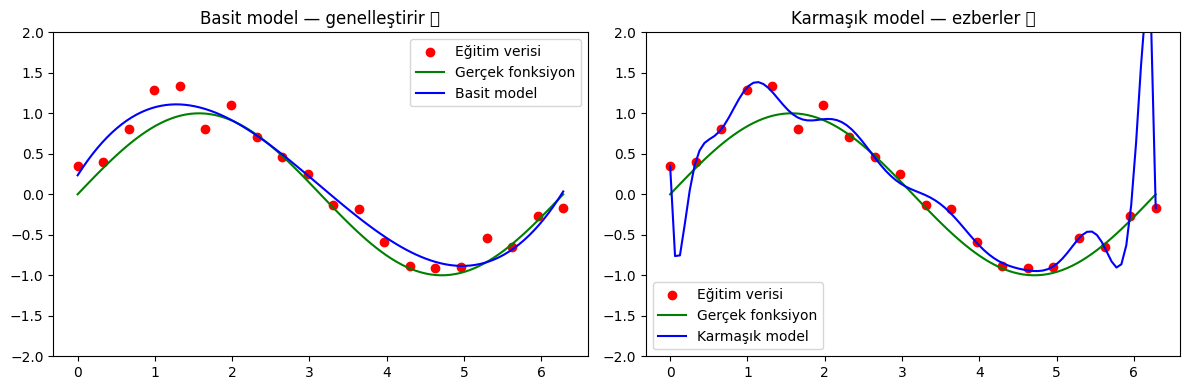

Karmaşık model eğitim noktalarından geçiyor
ama arada çılgınca sallanıyor → overfitting!


In [3]:
# ══════════════════════════════════════════════════════
# OVERFİTTİNG NEDİR? — SOMUT ÖRNEK
# ══════════════════════════════════════════════════════
#
# Eğitim verisi: 20 nokta
# Test verisi: yeni noktalar
#
# Basit model → genelleştirir (iyi)
# Karmaşık model → ezberleri (kötü)
# ══════════════════════════════════════════════════════

np.random.seed(0)

# Gerçek fonksiyon: y = sin(x)
x_train = np.linspace(0, 2*np.pi, 20)
y_train = np.sin(x_train) + np.random.randn(20) * 0.2  # biraz gürültü

x_test = np.linspace(0, 2*np.pi, 100)
y_test = np.sin(x_test)

# Basit model (3. derece polinom) — genelleştirir
coeffs_simple = np.polyfit(x_train, y_train, 3)
y_simple = np.polyval(coeffs_simple, x_test)

# Karmaşık model (15. derece polinom) — ezberler
coeffs_complex = np.polyfit(x_train, y_train, 15)
y_complex = np.polyval(coeffs_complex, x_test)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(x_train, y_train, color='red', label='Eğitim verisi')
plt.plot(x_test, y_test, 'g-', label='Gerçek fonksiyon')
plt.plot(x_test, y_simple, 'b-', label='Basit model')
plt.title("Basit model — genelleştirir ✅")
plt.legend()
plt.ylim(-2, 2)

plt.subplot(1, 2, 2)
plt.scatter(x_train, y_train, color='red', label='Eğitim verisi')
plt.plot(x_test, y_test, 'g-', label='Gerçek fonksiyon')
plt.plot(x_test, y_complex, 'b-', label='Karmaşık model')
plt.title("Karmaşık model — ezberler ❌")
plt.legend()
plt.ylim(-2, 2)

plt.tight_layout()
plt.show()

print("Karmaşık model eğitim noktalarından geçiyor")
print("ama arada çılgınca sallanıyor → overfitting!")

In [4]:
# ══════════════════════════════════════════════════════
# DROPOUT NASIL ÇALIŞIR?
# ══════════════════════════════════════════════════════
#
# Eğitim sırasında her nöronu p olasılıkla kapat
#   p = 0.5 → nöronların %50'si rastgele kapatılır
#
# Her iterasyonda farklı nöronlar kapanır
# Ağ tek bir nörona bağımlı olamaz
# → Genelleşmeyi öğrenir!
#
# Test sırasında:
#   Tüm nöronlar açık
#   Ama çıktıları (1-p) ile çarp → beklenti aynı kalır
#
# Inverted Dropout (daha yaygın):
#   Eğitimde: kapatılan nöronları sıfırla, açık olanları (1/p) ile böl
#   Testte: hiçbir şey yapma, direkt kullan
# ══════════════════════════════════════════════════════

def dropout_forward(x, p=0.5, train=True):
    """
    x:     girdi
    p:     her nöronun AÇIK kalma olasılığı (drop değil, keep!)
    train: eğitim mi test mi?
    """
    if train:
        # Rastgele maske oluştur
        # p olasılıkla 1 (açık), (1-p) olasılıkla 0 (kapalı)
        mask = (np.random.rand(*x.shape) < p) / p
        # /p → inverted dropout, test sırasında düzeltme gerekmez
        out = x * mask
    else:
        # Test sırasında hiçbir şey yapma
        mask = None
        out = x

    cache = (mask, p)
    return out, cache

def dropout_backward(grad_out, cache):
    mask, p = cache
    # Gradient sadece açık nöronlardan geçer
    grad_x = grad_out * mask
    return grad_x

# Test edelim
np.random.seed(0)
x = np.array([[1.0, 2.0, 3.0, 4.0, 5.0],
              [6.0, 7.0, 8.0, 9.0, 10.0]])

print("Girdi:")
print(x)

# Eğitim modu
out_train, cache = dropout_forward(x, p=0.5, train=True)
print("\nDropout sonrası (eğitim, p=0.5):")
print(out_train)
print("Bazı değerler sıfır → o nöronlar kapatıldı!")

# Test modu
out_test, _ = dropout_forward(x, p=0.5, train=False)
print("\nDropout sonrası (test):")
print(out_test)
print("Test'te hiçbir şey değişmedi!")

Girdi:
[[ 1.  2.  3.  4.  5.]
 [ 6.  7.  8.  9. 10.]]

Dropout sonrası (eğitim, p=0.5):
[[ 0.  0.  0.  0. 10.]
 [ 0. 14.  0.  0. 20.]]
Bazı değerler sıfır → o nöronlar kapatıldı!

Dropout sonrası (test):
[[ 1.  2.  3.  4.  5.]
 [ 6.  7.  8.  9. 10.]]
Test'te hiçbir şey değişmedi!


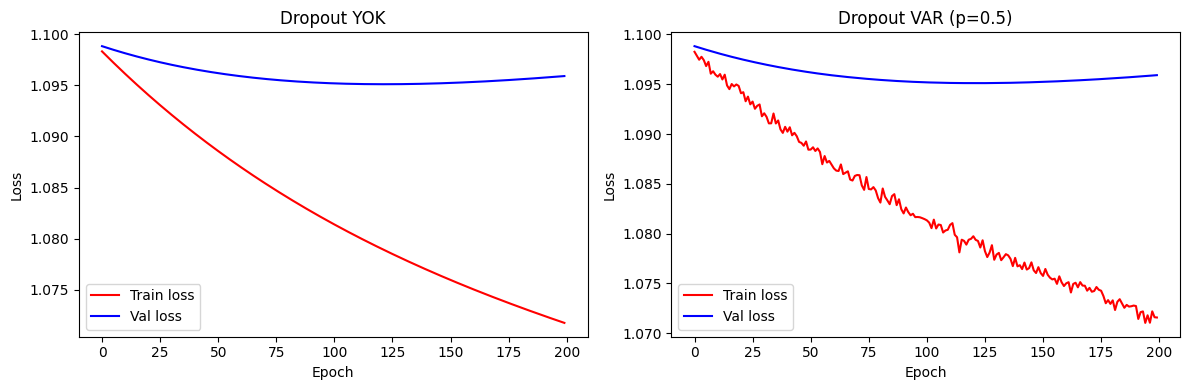

Dropout YOK → train: 1.072, val: 1.096
Dropout VAR → train: 1.072, val: 1.096


In [5]:
# ══════════════════════════════════════════════════════
# DROPOUT İLE vs DROPOUT OLMADAN EĞİTİM
# ══════════════════════════════════════════════════════
#
# Eğitim loss vs Validation loss karşılaştıralım
#
# Overfitting işareti:
#   Eğitim loss → düşüyor
#   Validation loss → yükseliyor (model ezberliyor)
#
# Dropout ile:
#   İkisi de birlikte düşer
# ══════════════════════════════════════════════════════

np.random.seed(42)

# Küçük veri seti — overfitting'e açık
N_train, N_val = 50, 200
D, H, C = 20, 100, 3

X_train = np.random.randn(N_train, D)
y_train = np.random.randint(0, C, N_train)
X_val   = np.random.randn(N_val, D)
y_val   = np.random.randint(0, C, N_val)

def train(use_dropout=False, epochs=200, lr=0.01):
    W1 = np.random.randn(D, H) * 0.01
    b1 = np.zeros(H)
    W2 = np.random.randn(H, C) * 0.01
    b2 = np.zeros(C)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # FORWARD — eğitim
        h_raw = X_train @ W1 + b1
        h = np.maximum(0, h_raw)

        if use_dropout:
            h, cache_drop = dropout_forward(h, p=0.5, train=True)

        skorlar = h @ W2 + b2
        e_s = np.exp(skorlar - np.max(skorlar, axis=1, keepdims=True))
        probs = e_s / np.sum(e_s, axis=1, keepdims=True)
        loss = -np.mean(np.log(probs[np.arange(N_train), y_train]))
        train_losses.append(loss)

        # BACKWARD
        grad_s = probs.copy()
        grad_s[np.arange(N_train), y_train] -= 1
        grad_s /= N_train
        grad_W2 = h.T @ grad_s
        grad_b2 = np.sum(grad_s, axis=0)
        grad_h = grad_s @ W2.T

        if use_dropout:
            grad_h = dropout_backward(grad_h, cache_drop)

        grad_h = grad_h * (h_raw > 0)
        grad_W1 = X_train.T @ grad_h
        grad_b1 = np.sum(grad_h, axis=0)

        W1 -= lr * grad_W1
        b1 -= lr * grad_b1
        W2 -= lr * grad_W2
        b2 -= lr * grad_b2

        # VALİDATION — test modunda dropout yok
        h_val = np.maximum(0, X_val @ W1 + b1)
        s_val = h_val @ W2 + b2
        e_val = np.exp(s_val - np.max(s_val, axis=1, keepdims=True))
        p_val = e_val / np.sum(e_val, axis=1, keepdims=True)
        val_loss = -np.mean(np.log(p_val[np.arange(N_val), y_val]))
        val_losses.append(val_loss)

    return train_losses, val_losses

# Eğit
np.random.seed(0)
train_no, val_no = train(use_dropout=False)
np.random.seed(0)
train_do, val_do = train(use_dropout=True)

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_no, 'r-', label='Train loss')
axes[0].plot(val_no, 'b-', label='Val loss')
axes[0].set_title("Dropout YOK")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(train_do, 'r-', label='Train loss')
axes[1].plot(val_do, 'b-', label='Val loss')
axes[1].set_title("Dropout VAR (p=0.5)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Dropout YOK → train: {train_no[-1]:.3f}, val: {val_no[-1]:.3f}")
print(f"Dropout VAR → train: {train_do[-1]:.3f}, val: {val_do[-1]:.3f}")

In [6]:
# ══════════════════════════════════════════════════════
# DROPOUT ÖZET
# ══════════════════════════════════════════════════════

print("╔══════════════════════════════════════════════════╗")
print("║                 DROPOUT ÖZET                     ║")
print("╠══════════════════════════════════════════════════╣")
print("║                                                  ║")
print("║  Problem: Overfitting                            ║")
print("║    Train loss düşer, Val loss düşmez             ║")
print("║    Model ezberler, genelleyemez                  ║")
print("║                                                  ║")
print("║  Çözüm: Dropout                                  ║")
print("║    Eğitimde nöronları rastgele kapat             ║")
print("║    Her seferinde farklı ağ yapısı                ║")
print("║    Model tek nörona bağımlı olamaz               ║")
print("║                                                  ║")
print("║  Inverted Dropout:                               ║")
print("║    Eğitim: mask = (rand < p) / p                 ║")
print("║    Test:   hiçbir şey yapma                      ║")
print("║                                                  ║")
print("║  p değeri (keep probability):                    ║")
print("║    p=0.5 → %50 nöron açık (yaygın)               ║")
print("║    p=0.8 → %80 nöron açık (hafif dropout)        ║")
print("║    p=1.0 → dropout yok                           ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║                 DROPOUT ÖZET                     ║
╠══════════════════════════════════════════════════╣
║                                                  ║
║  Problem: Overfitting                            ║
║    Train loss düşer, Val loss düşmez             ║
║    Model ezberler, genelleyemez                  ║
║                                                  ║
║  Çözüm: Dropout                                  ║
║    Eğitimde nöronları rastgele kapat             ║
║    Her seferinde farklı ağ yapısı                ║
║    Model tek nörona bağımlı olamaz               ║
║                                                  ║
║  Inverted Dropout:                               ║
║    Eğitim: mask = (rand < p) / p                 ║
║    Test:   hiçbir şey yapma                      ║
║                                                  ║
║  p değeri (keep probability):                    ║
║    p=0.5 → %50 nöron açık (yaygın)          